In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [10]:
data = {
    "area": [850, 900, 950, 1000, 1100, 1200, 1350, 1500, 1650, 1800,
             2000, 2200, 2400, 2600, 3000],
    "price": [42, 45, 48, 52, 58, 62, 66, 70, 74, 78,
              82, 85, 88, 90, 65] 
}

df = pd.DataFrame(data)
df

,area,price
0,850,42
1,900,45
2,950,48
3,1000,52
4,1100,58
5,1200,62
6,1350,66
7,1500,70
8,1650,74
9,1800,78


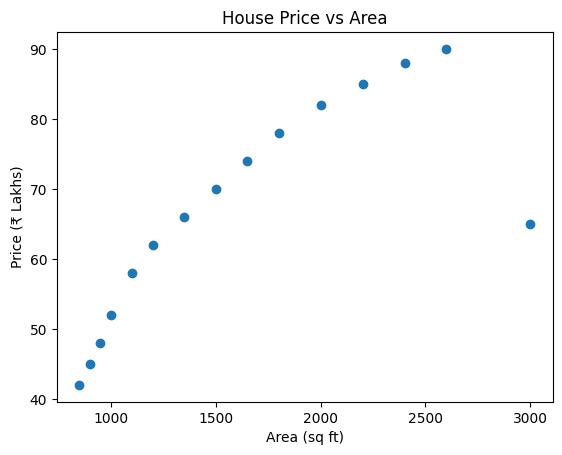

In [12]:
plt.figure()
plt.scatter(df["area"], df["price"])
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (₹ Lakhs)")
plt.title("House Price vs Area")
plt.show()

In [ ]:
#Outlier Remove

In [14]:
X = df[["area"]]
y = df["price"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [30]:
model.coef_, model.intercept_
#y=10.70486683*Area+69.75

(array([10.70486683]), 69.75)

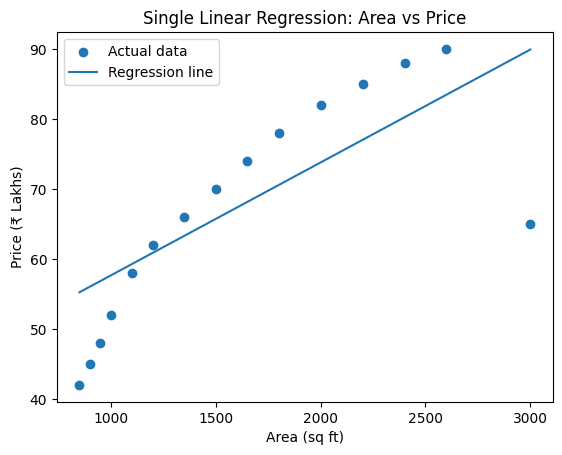

In [32]:
# For smooth line
X_sorted = X.sort_values(by="area")
X_sorted_scaled = scaler.transform(X_sorted)

y_line = model.predict(X_sorted_scaled)

plt.figure()
plt.scatter(df["area"], df["price"], label="Actual data")
plt.plot(X_sorted["area"], y_line, label="Regression line")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (₹ Lakhs)")
plt.title("Single Linear Regression: Area vs Price")
plt.legend()
plt.show()

In [34]:
y_pred_train=model.predict(X_train_scaled)
y_pred_test=model.predict(X_test_scaled)

In [42]:
r2_train = r2_score(y_train, y_pred_train)
r2_train

0.5469345073666666

In [44]:
r2_test = r2_score(y_test, y_pred_test)
r2_test

0.5495887296434465